In [1]:
# MÓDULOS E IMPORTAÇÕES
import kagglehub

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns       # Referência de estudo: https://www.dannidanliu.com/introduction-to-s/

from datetime import date, datetime

In [2]:
# Loading data
file = 'air traffic.csv'
df_original = pd.read_csv(f'data\{file}')

In [3]:
df_original

,Year,Month,Dom_Pax,Int_Pax,Pax,Dom_Flt,Int_Flt,Flt,Dom_RPM,Int_RPM,RPM,Dom_ASM,Int_ASM,ASM,Dom_LF,Int_LF,LF
0,2003,1,"43,032,450","4,905,830","47,938,280","785,160","57,667","842,827","36,211,422","12,885,980","49,097,402","56,191,300","17,968,572","74,159,872",64.44,71.71,66.20
1,2003,2,"41,166,780","4,245,366","45,412,146","690,351","51,259","741,610","34,148,439","10,715,468","44,863,907","50,088,434","15,587,880","65,676,314",68.18,68.74,68.31
2,2003,3,"49,992,700","5,008,613","55,001,313","797,194","58,926","856,120","41,774,564","12,567,068","54,341,633","57,592,901","17,753,174","75,346,075",72.53,70.79,72.12
3,2003,4,"47,033,260","4,345,444","51,378,704","766,260","55,005","821,265","39,465,980","10,370,592","49,836,572","54,639,679","15,528,761","70,168,440",72.23,66.78,71.02
4,2003,5,"49,152,352","4,610,834","53,763,186","789,397","55,265","844,662","41,001,934","11,575,026","52,576,960","55,349,897","15,629,821","70,979,718",74.08,74.06,74.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,2023,5,"71,423,653","10,358,666","81,782,319","667,331","71,924","739,255","66,743,565","26,805,432","93,548,998","77,821,407","31,950,687","109,772,094",85.77,83.90,85.22
245,2023,6,"72,482,621","11,544,505","84,027,126","661,293","75,279","736,572","68,789,127","29,883,465","98,672,591","78,058,358","33,410,671","111,469,028",88.13,89.44,88.52
246,2023,7,"75,378,157","12,432,615","87,810,772","684,939","79,738","764,677","72,267,904","31,376,000","103,643,904","81,986,010","35,326,191","117,312,202",88.15,88.82,88.35
247,2023,8,"71,477,988","11,572,149","83,050,137","691,482","77,137","768,619","67,933,484","29,938,507","97,871,992","81,997,399","34,908,793","116,906,192",82.85,85.76,83.72


In [4]:
# Processing data
df = df_original.copy()

df = df[['Year', 'Month', 'Flt']]

df['date'] = pd.to_datetime(df[['Year', 'Month']].assign(day=1))

df['flights'] = df['Flt'].str.replace(',', '').astype('Int32')

df = df.drop(columns=['Year', 'Month', 'Flt'])

df = df.sort_values('date')#.set_index('Date')


In [5]:
df

,date,flights
0,2003-01-01,842827
1,2003-02-01,741610
2,2003-03-01,856120
3,2003-04-01,821265
4,2003-05-01,844662
...,...,...
244,2023-05-01,739255
245,2023-06-01,736572
246,2023-07-01,764677
247,2023-08-01,768619


In [7]:
df['flights'].describe()

count            249.0
mean     771486.883534
std      115686.728629
min           222280.0
25%           727898.0
50%           779011.0
75%           848650.0
max           964102.0
Name: flights, dtype: Float64

# Data Visualization

<Axes: ylabel='flights'>

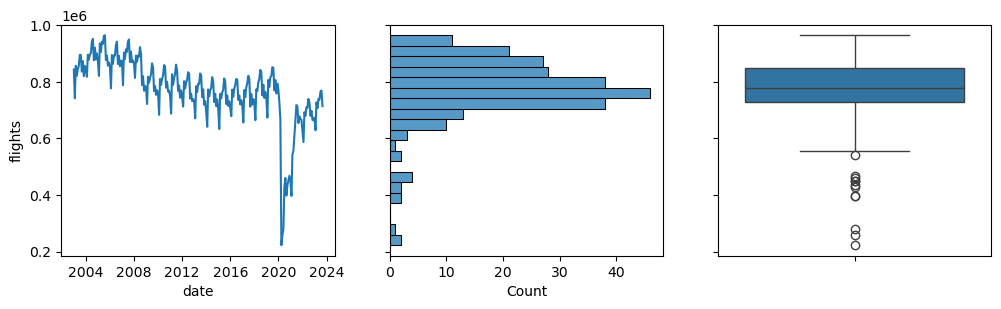

In [42]:
f, (ax_plot, ax_hist, ax_box) = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 3))

sns.lineplot(x = df['date'], y = df['flights'], ax=ax_plot)
sns.histplot(y = df['flights'], ax=ax_hist)
sns.boxplot(df['flights'], ax=ax_box)

# orient="h"

In [75]:
# Segmentação temporal

df_2003_to_2008 = df[df['date'] <= '2008-08-01']
df_2008_to_2019 = df[('2008-08-01' < df['date']) & (df['date'] <= '2019-12-01')]
df_2020_to_2023 = df['2019-12-01' < df['date']]

<Axes: xlabel='date', ylabel='flights'>

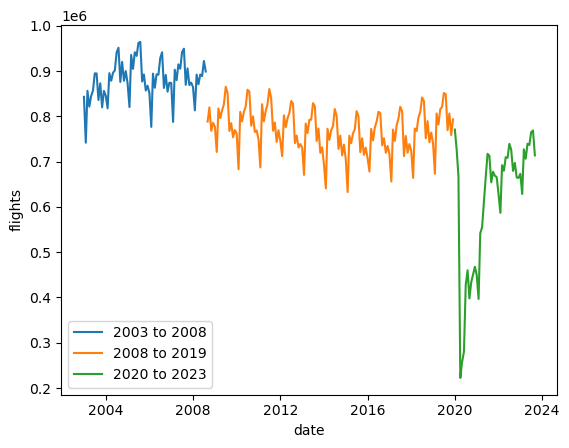

In [76]:
sns.lineplot(x=df_2003_to_2008['date'], y=df_2003_to_2008['flights'], label="2003 to 2008")
sns.lineplot(x=df_2008_to_2019['date'], y=df_2008_to_2019['flights'], label="2008 to 2019")
sns.lineplot(x=df_2020_to_2023['date'], y=df_2020_to_2023['flights'], label="2020 to 2023")

# sns.lineplot(
#     {"2003 to 2008": df_2003_to_2008['flights'], 
#      "2008 to 2019": df_2008_to_2019['flights'], 
#      "2020 to 2023": df_2020_to_2023['flights']
#     }, 
# )

<Axes: ylabel='Count'>

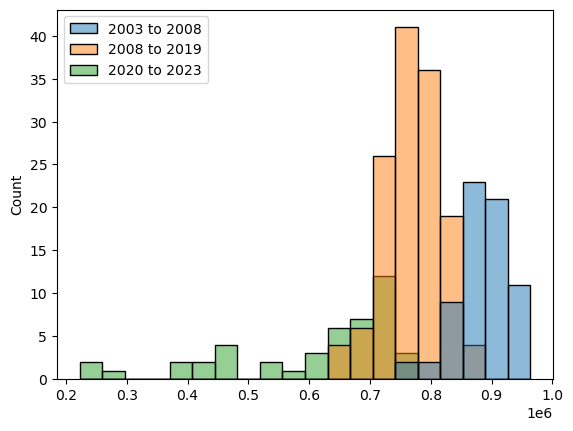

In [77]:
sns.histplot(
    {"2003 to 2008": df_2003_to_2008['flights'], 
     "2008 to 2019": df_2008_to_2019['flights'], 
     "2020 to 2023": df_2020_to_2023['flights']
    }, 
)

<Axes: >

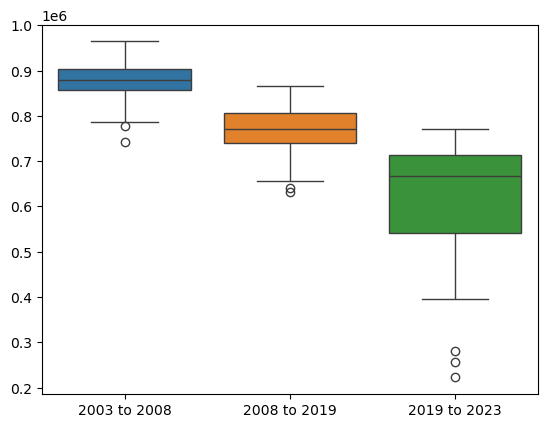

In [78]:
sns.boxplot(
    {"2003 to 2008": df_2003_to_2008['flights'], 
     "2008 to 2019": df_2008_to_2019['flights'], 
     "2019 to 2023": df_2020_to_2023['flights']
    }, 
)

# Linear Regression Models

In [81]:
# Division between testing and training data
df_train_and_validation = pd.concat([df_2003_to_2008, df_2008_to_2019])
df_test = df_2020_to_2023

In [154]:
# Division between training and validation data

# df must be sorted chronologically!
# 80 % for training and 20 % for validation
split_index = int(len(df_train_and_validation) * 0.8)

df_train = df_train_and_validation.iloc[:split_index]   # 163 rows × 1 columns
df_valid = df_train_and_validation.iloc[split_index:]   #  41 rows × 1 columns

In [155]:
df_train

,date,flights
0,2003-01-01,842827
1,2003-02-01,741610
2,2003-03-01,856120
3,2003-04-01,821265
4,2003-05-01,844662
...,...,...
158,2016-03-01,771996
159,2016-04-01,746635
160,2016-05-01,775065
161,2016-06-01,788704


In [182]:
# Processing data for training for different hyperparameters

def process_training_data(df_train, K):

    X_train = pd.DataFrame()
    
    for i in range(1, K + 1):
        v_train = df_train['flights'].rename(f'x_{i}').shift(i)
        X_train = pd.concat([X_train, v_train], axis=1)

    y_train = df_train.copy()
    y_train.rename(columns={'flights': 'y'}, inplace=True)

    df_aux = pd.concat([y_train, X_train], axis=1).dropna().reset_index(drop=True)  # for dropping redundant rows with null values

    target = df_aux.pop('y')
    features = df_aux.drop(columns='date')

    return features, target

In [183]:
X, y = process_training_data(df_train, 2)

In [184]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
y_pred = model.predict() 

In [ ]:
# Import metrics.
from sklearn.metrics import mean_squared_error, r2_score


# Calculate and print R^2 score.
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.4f}")

0    844662
1    856576
2    894576
3    894497
4    835821
Name: y, dtype: Int32

In [176]:
from IPython.display import display
display(target)

0      844662
1      856576
2      894576
3      894497
4      835821
        ...  
154    771996
155    746635
156    775065
157    788704
158    809770
Name: y, Length: 159, dtype: Int32

In [174]:
features

,x_1,x_2,x_3,x_4
0,821265,856120,741610,842827
1,844662,821265,856120,741610
2,856576,844662,821265,856120
3,894576,856576,844662,821265
4,894497,894576,856576,844662
...,...,...,...,...
154,678081,707237,730730,714668
155,771996,678081,707237,730730
156,746635,771996,678081,707237
157,775065,746635,771996,678081
